# 相関 (Correlation) の概念

このノートブックでは、信号処理における重要な概念である「自己相関 (Autocorrelation)」と「相互相関 (Cross-correlation)」について、Pythonコードとグラフを用いて解説します。

※ グラフのラベルは文字化けを防ぐため英語表記にしています。

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# グラフの表示設定
# %matplotlib inline
# 日本語フォントが見つからない場合のエラーを防ぐため、デフォルトフォントを使用します

## 1. 自己相関 (Autocorrelation)

自己相関は、ある信号と、その信号自身を時間的にずらしたものとの間の類似度を表します。
これは、信号の中に周期性があるか、あるいは繰り返されるパターンがあるかを見つけるのに役立ちます。

### 例：周期信号の自己相関
ノイズの乗った正弦波を使って、自己相関を確認してみます。

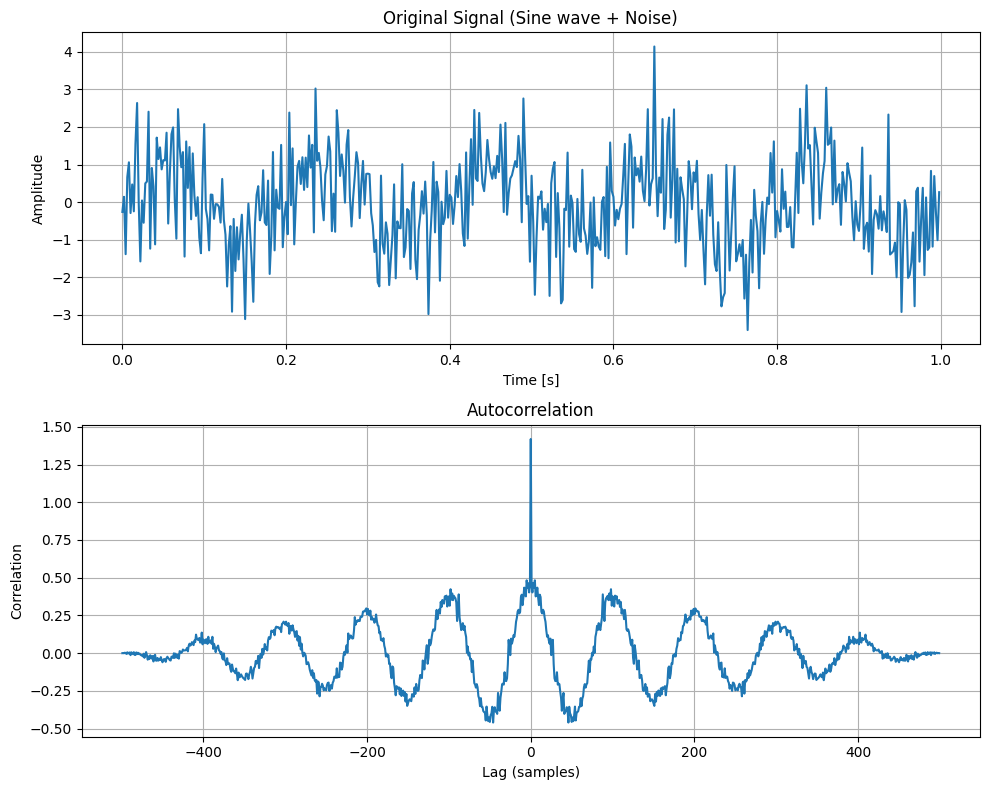

In [11]:
# 時間軸の作成
N = 500
t = np.linspace(0, 1, N, endpoint=False)
frequency = 5  # 周波数 5Hz

# 信号の生成 (正弦波 + ノイズ)
signal = np.sin(2 * np.pi * frequency * t) + 1 * np.random.randn(len(t))

# 自己相関の計算
# mode='full' は、重なり合うすべての部分で相関を計算します
correlation = np.correlate(signal, signal, mode='full')/N

# ラグ（ずれ）の軸を作成
lags = np.arange(-len(t) + 1, len(t))

# グラフの描画
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(t, signal)
ax1.set_title('Original Signal (Sine wave + Noise)')
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Amplitude')
ax1.grid(True)

ax2.plot(lags, correlation)
ax2.set_title('Autocorrelation')
ax2.set_xlabel('Lag (samples)')
ax2.set_ylabel('Correlation')
ax2.grid(True)

plt.tight_layout()
plt.show()

**解説:**
- グラフラグが0のとき（ずれがないとき）、信号は完全に重なるため、相関値は最大になります。
- 信号に周期性があるため、ラグが増えても定期的に相関値のピークが現れます。
- ノイズ成分はランダムなので、特定のラグ以外では相関が低くなり、信号の周期性が明確に浮かび上がります。

## 2. 相互相関 (Cross-correlation)

相互相関は、2つの異なる信号間の類似度を表します。
これは、ある信号の中に特定のパターンが含まれているかを探したり（パターンマッチング）、2つの信号の時間的な遅れ（タイムラグ）を推定したりするのに使われます。

### 例：信号の遅延推定
送信信号と、それが遅れて届いた受信信号（ノイズあり）との相互相関をとってみます。

Detected delay: 200 samples


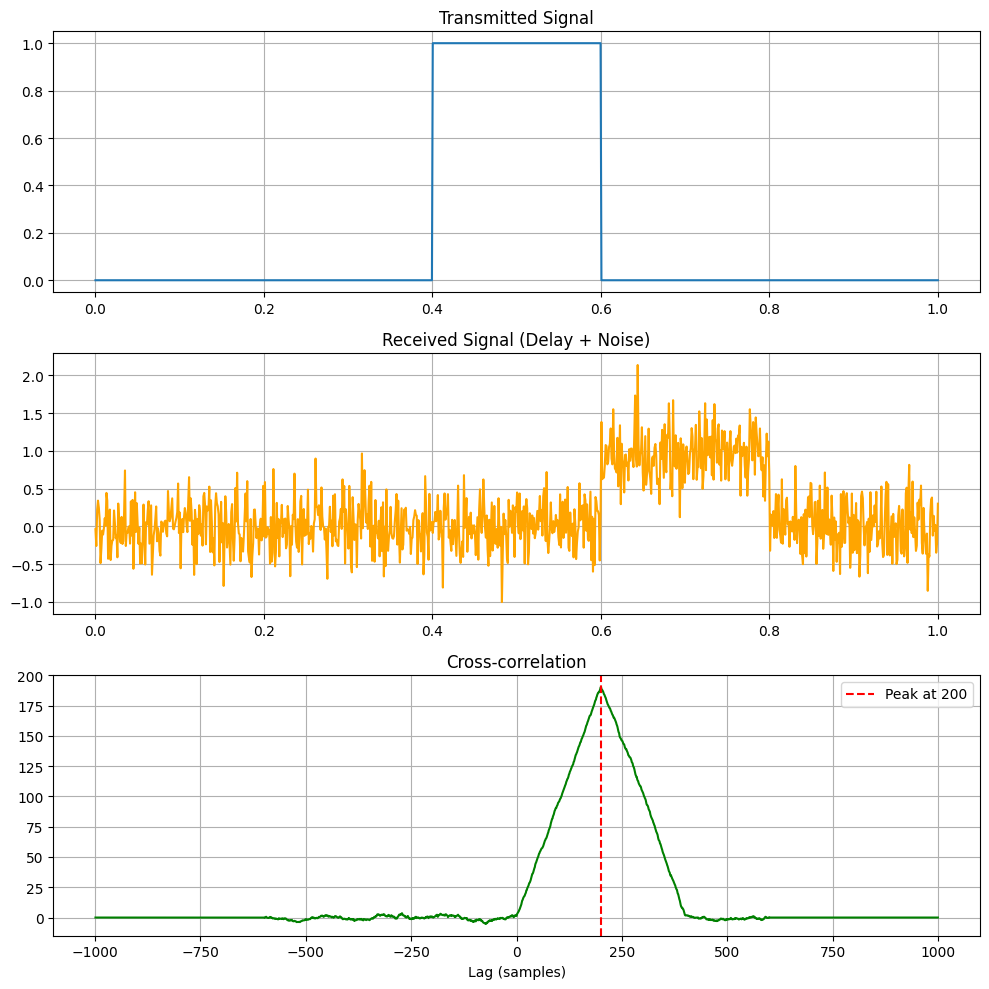

In [12]:
# 元の信号 (パルスのような形状)
t = np.linspace(0, 1, 1000)
sig_sent = np.zeros_like(t)
sig_sent[400:600] = 1.0  # 真ん中あたりに矩形波

# 受信信号 (遅延 + ノイズ)
shift_amount = 200  # サンプル数で200の遅延
sig_received = np.roll(sig_sent, shift_amount) + 0.3 * np.random.randn(len(t))

# 相互相関の計算
cross_corr = np.correlate(sig_received, sig_sent, mode='full')
lags = np.arange(-len(t) + 1, len(t))

# 最大相関となるラグを見つける
lag_max = lags[np.argmax(cross_corr)]
print(f"Detected delay: {lag_max} samples")

# グラフの描画
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 10))

ax1.plot(t, sig_sent)
ax1.set_title('Transmitted Signal')
ax1.grid(True)

ax2.plot(t, sig_received, color='orange')
ax2.set_title('Received Signal (Delay + Noise)')
ax2.grid(True)

ax3.plot(lags, cross_corr, color='green')
ax3.set_title('Cross-correlation')
ax3.set_xlabel('Lag (samples)')
ax3.axvline(lag_max, color='red', linestyle='--', label=f'Peak at {lag_max}')
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.show()

**解説:**
- 送信信号と受信信号の波形を見ると、受信信号はずれており、かつノイズが乗っています。
- 相互相関のグラフを見ると、特定のラグ（この場合は約200）で鋭いピークが現れます。
- このピークの位置が、2つの信号の間の時間的なずれを表しています。